# XGBoost-v6 Price Forecast (t+5, Event-Based)

Notebook ini mencoba **model XGBoost untuk prediksi harga** (Close t+5) sebagai eksperimen terpisah dari model directional.


## Tujuan dan Batasan

- Target utama: `Close(t+5)`.
- Teknik model: XGBoost regresi pada `log-return t+5`, lalu dikonversi ke harga.
- Output utama untuk bisnis: **price range** `P10 / P50 / P90` (bukan hanya 1 angka).
- Evaluasi: baseline lock (pilih baseline di valid, lock ke test), purged split, yearly walk-forward.
- Gate utama: **raw XGBoost** harus lulus hard-fail per fold test vs baseline (blend hanya diagnostik tambahan).



In [1]:
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from sklearn.metrics import mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor

try:
    import seaborn as sns
    sns.set_theme(style="whitegrid")
except Exception:
    plt.style.use("seaborn-v0_8-whitegrid")

try:
    import optuna
except Exception:
    optuna = None

# Silence notebook-only tqdm widget warnings (harmless for model training).
try:
    from tqdm import TqdmWarning
    warnings.filterwarnings("ignore", category=TqdmWarning)
except Exception:
    pass

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

DATA_PATH = ROOT / "data" / "processed data" / "ali_f_event_model_ready_v3.csv"
OUT_DIR = ROOT / "data" / "processed data"

SEED = 42
H = 5
START_DATE = "2020-01-01"
DROP_LONG_GAP = True
TRAIN_WINDOW_YEARS = 3
MIN_TRAIN_ROWS = 180
MIN_VALID_ROWS = 80
MIN_TEST_ROWS = 80
MIN_TRAIN_YEARS = 2
EARLY_STOPPING = 100
INTERVAL_LOW_Q = 0.10
INTERVAL_HIGH_Q = 0.90

# No-harm gate + regime activation.
NOHARM_TAU_MULT_DEFAULT = 0.75
NOHARM_TAU_MULT_MIN = 0.20
REGIME_VOL_Z_DEFAULT = 0.75
REGIME_VOL_Z_MIN = 0.25
REGIME_VOL_Z_MAX = 2.00
REGIME_ACTIVE_TARGET_LOW = 0.20
REGIME_ACTIVE_TARGET_HIGH = 0.40

# Must-win tuning policy (valid stream must outperform locked baseline).
MUST_WIN_VALID_EPS = 1e-4
MUST_WIN_MEAN_PENALTY = 4.0
MUST_WIN_FOLD_PENALTY = 2.0
WORST_FOLD_POS_PENALTY = 3.0
REGIME_ACTIVE_PENALTY = 0.8

USE_OPTUNA = True
OPTUNA_N_TRIALS = 80
OPTUNA_TIMEOUT_SEC = 1800
OPTUNA_MIN_FOLDS = 3
OPTUNA_USE_PRUNER = True
OPTUNA_PRUNER_STARTUP_TRIALS = 12
OPTUNA_PRUNER_WARMUP_STEPS = 1

REG_PARAMS = {
    "objective": "reg:absoluteerror",
    "n_estimators": 900,
    "learning_rate": 0.03,
    "max_depth": 3,
    "min_child_weight": 8,
    "subsample": 0.9,
    "colsample_bytree": 0.9,
    "gamma": 0.02,
    "reg_alpha": 0.8,
    "reg_lambda": 2.0,
}

REG_PARAMS_USED = REG_PARAMS.copy()
NOHARM_TAU_MULT_USED = NOHARM_TAU_MULT_DEFAULT
REGIME_VOL_Z_USED = REGIME_VOL_Z_DEFAULT
selected_params_source = "fixed_default_no_optuna"

if USE_OPTUNA and optuna is None:
    print("Optuna not available -> fallback to fixed REG_PARAMS")
    USE_OPTUNA = False

print("DATA_PATH:", DATA_PATH)
print("TARGET_HORIZON:", H)
print("REG_PARAMS(default):", REG_PARAMS)
print("NOHARM_TAU_MULT_DEFAULT:", NOHARM_TAU_MULT_DEFAULT, "| floor:", NOHARM_TAU_MULT_MIN)
print("REGIME_VOL_Z_DEFAULT:", REGIME_VOL_Z_DEFAULT)
print("MUST_WIN_VALID_EPS:", MUST_WIN_VALID_EPS)
print("USE_OPTUNA:", USE_OPTUNA, "| trials:", OPTUNA_N_TRIALS, "| timeout:", OPTUNA_TIMEOUT_SEC)
print("INTERVAL:", (INTERVAL_LOW_Q, 0.50, INTERVAL_HIGH_Q))


DATA_PATH: /home/sdo/Project/Machine Learning/INALUM/data/processed data/ali_f_event_model_ready_v3.csv
TARGET_HORIZON: 5
REG_PARAMS(default): {'objective': 'reg:absoluteerror', 'n_estimators': 900, 'learning_rate': 0.03, 'max_depth': 3, 'min_child_weight': 8, 'subsample': 0.9, 'colsample_bytree': 0.9, 'gamma': 0.02, 'reg_alpha': 0.8, 'reg_lambda': 2.0}
NOHARM_TAU_MULT_DEFAULT: 0.75 | floor: 0.2
REGIME_VOL_Z_DEFAULT: 0.75
MUST_WIN_VALID_EPS: 0.0001
USE_OPTUNA: True | trials: 80 | timeout: 1800
INTERVAL: (0.1, 0.5, 0.9)


In [2]:
# Load data + quality context

df = pd.read_csv(DATA_PATH, parse_dates=["Date"]).sort_values("Date").reset_index(drop=True)

df["is_flat_ohlc"] = (
    (df["Open"] == df["High"]) & (df["High"] == df["Low"]) & (df["Low"] == df["Close"])
)

df_quality = pd.DataFrame([
    {
        "rows": len(df),
        "date_min": df["Date"].min().date(),
        "date_max": df["Date"].max().date(),
        "flat_ohlc_pct": float(df["is_flat_ohlc"].mean()),
        "long_gap_pct": float(df["is_long_gap"].fillna(False).mean()),
    }
])
df_quality


,rows,date_min,date_max,flat_ohlc_pct,long_gap_pct
0,2336,2014-05-06,2026-03-04,0.80351,0.012414


In [3]:
# Build modeling frame (price target)

def build_price_frame(df_all: pd.DataFrame) -> pd.DataFrame:
    d = df_all.copy()
    d = d[d["Date"] >= pd.Timestamp(START_DATE)].copy()

    if DROP_LONG_GAP:
        d = d[~d["is_long_gap"].fillna(False)].copy()

    d["hl_spread_pct"] = (d["High"] - d["Low"]) / d["Close"]
    d["oc_spread_pct"] = (d["Close"] - d["Open"]) / d["Open"]
    d["volume_log1p"] = np.log1p(d["Volume"])

    for lag in (1, 2, 3, 5, 8, 10):
        d[f"ret_lag_{lag}"] = d["Return"].shift(lag)
        d[f"vol_lag_{lag}"] = d["Volume"].shift(lag)
        d[f"gap_lag_{lag}"] = d["gap_days"].shift(lag)

    d["ret_roll_mean_5"] = d["Return"].rolling(5, min_periods=3).mean()
    d["ret_roll_mean_10"] = d["Return"].rolling(10, min_periods=5).mean()
    d["ret_roll_std_10"] = d["Return"].rolling(10, min_periods=5).std()
    d["ret_roll_std_20"] = d["Return"].rolling(20, min_periods=8).std()

    d["close_mom_5"] = d["Close"].pct_change(5)
    d["close_mom_10"] = d["Close"].pct_change(10)

    d["month"] = d["Date"].dt.month
    d["quarter"] = d["Date"].dt.quarter
    d["dow"] = d["Date"].dt.dayofweek

    d[f"target_date_t{H}"] = d["Date"].shift(-H)
    d[f"target_close_t{H}"] = d["Close"].shift(-H)
    d[f"target_ret_t{H}"] = (d[f"target_close_t{H}"] / d["Close"]) - 1.0
    d[f"target_logret_t{H}"] = np.log(d[f"target_close_t{H}"] / d["Close"])

    return d


def build_yearly_walk_forward_folds(df_in: pd.DataFrame) -> list[dict]:
    years = sorted(df_in["Date"].dt.year.dropna().unique().tolist())
    folds = []

    for valid_year in years[MIN_TRAIN_YEARS:]:
        test_year = valid_year + 1
        if test_year not in years:
            continue

        train_end = pd.Timestamp(f"{valid_year - 1}-12-31")
        valid_start = pd.Timestamp(f"{valid_year}-01-01")
        valid_end = pd.Timestamp(f"{valid_year}-12-31")
        test_start = pd.Timestamp(f"{test_year}-01-01")
        test_end = pd.Timestamp(f"{test_year}-12-31")

        if TRAIN_WINDOW_YEARS is not None and int(TRAIN_WINDOW_YEARS) > 0:
            train_start = pd.Timestamp(f"{valid_year - int(TRAIN_WINDOW_YEARS)}-01-01")
            train_mask = (df_in["Date"] >= train_start) & (df_in["Date"] <= train_end)
            train_start_str = str(train_start.date())
        else:
            train_mask = df_in["Date"] <= train_end
            train_start_str = None

        folds.append(
            {
                "fold_name": f"valid_{valid_year}_test_{test_year}",
                "fold_order": len(folds) + 1,
                "train_start": train_start_str,
                "train_end": str(train_end.date()),
                "valid_start": str(valid_start.date()),
                "valid_end": str(valid_end.date()),
                "test_start": str(test_start.date()),
                "test_end": str(test_end.date()),
                "rows_train_raw": int(train_mask.sum()),
                "rows_valid_raw": int(((df_in["Date"] >= valid_start) & (df_in["Date"] <= valid_end)).sum()),
                "rows_test_raw": int(((df_in["Date"] >= test_start) & (df_in["Date"] <= test_end)).sum()),
            }
        )

    return folds


def split_by_fold_raw(df_in: pd.DataFrame, fold: dict):
    train_end = pd.Timestamp(fold["train_end"])
    train_start_raw = fold.get("train_start")
    if train_start_raw:
        train_start = pd.Timestamp(train_start_raw)
        tr = df_in[(df_in["Date"] >= train_start) & (df_in["Date"] <= train_end)].copy()
    else:
        tr = df_in[df_in["Date"] <= train_end].copy()
    va = df_in[(df_in["Date"] >= pd.Timestamp(fold["valid_start"])) & (df_in["Date"] <= pd.Timestamp(fold["valid_end"]))].copy()
    te = df_in[(df_in["Date"] >= pd.Timestamp(fold["test_start"])) & (df_in["Date"] <= pd.Timestamp(fold["test_end"]))].copy()
    return tr, va, te


def split_by_fold_purged(df_in: pd.DataFrame, fold: dict):
    td_col = f"target_date_t{H}"

    train_end = pd.Timestamp(fold["train_end"])
    train_start_raw = fold.get("train_start")
    train_start = pd.Timestamp(train_start_raw) if train_start_raw else None

    valid_start = pd.Timestamp(fold["valid_start"])
    valid_end = pd.Timestamp(fold["valid_end"])
    test_start = pd.Timestamp(fold["test_start"])
    test_end = pd.Timestamp(fold["test_end"])

    if train_start is not None:
        tr = df_in[(df_in["Date"] >= train_start) & (df_in["Date"] <= train_end) & (df_in[td_col] <= train_end)].copy()
    else:
        tr = df_in[(df_in["Date"] <= train_end) & (df_in[td_col] <= train_end)].copy()

    va = df_in[(df_in["Date"] >= valid_start) & (df_in["Date"] <= valid_end) & (df_in[td_col] <= valid_end)].copy()
    te = df_in[(df_in["Date"] >= test_start) & (df_in["Date"] <= test_end) & (df_in[td_col] <= test_end)].copy()
    return tr, va, te


FEATURES = [
    "Close", "Volume", "dow", "quarter",
    "ret_lag_1", "ret_lag_5", "ret_roll_mean_5", "ret_roll_mean_10", "ret_roll_std_10", "ret_roll_std_20",
    "vol_lag_1", "vol_lag_5", "gap_lag_1", "hl_spread_pct", "oc_spread_pct", "close_mom_5", "close_mom_10",
]

st = build_price_frame(df)
folds = build_yearly_walk_forward_folds(st)

print("rows in modeling frame:", len(st))
print("folds:", len(folds))
pd.DataFrame(folds)


rows in modeling frame: 1414
folds: 4


,fold_name,fold_order,train_start,train_end,valid_start,valid_end,test_start,test_end,rows_train_raw,rows_valid_raw,rows_test_raw
0,valid_2022_test_2023,1,2019-01-01,2021-12-31,2022-01-01,2022-12-31,2023-01-01,2023-12-31,438,199,247
1,valid_2023_test_2024,2,2020-01-01,2022-12-31,2023-01-01,2023-12-31,2024-01-01,2024-12-31,637,247,237
2,valid_2024_test_2025,3,2021-01-01,2023-12-31,2024-01-01,2024-12-31,2025-01-01,2025-12-31,644,237,251
3,valid_2025_test_2026,4,2022-01-01,2024-12-31,2025-01-01,2025-12-31,2026-01-01,2026-12-31,683,251,42


In [4]:
# Leakage audit (simple but strict)

audit_rows = []
violations = []

base_cols = FEATURES + [f"target_date_t{H}", f"target_close_t{H}", f"target_logret_t{H}", "Date", "Close"]
d = st.dropna(subset=base_cols).copy().sort_values("Date").reset_index(drop=True)

if int(d["Date"].duplicated().sum()) > 0:
    violations.append({"scope": "global", "violation": "duplicate_dates"})
if int((d[f"target_date_t{H}"] <= d["Date"]).sum()) > 0:
    violations.append({"scope": "global", "violation": "target_not_strictly_future"})

for fold in folds:
    tr, va, te = split_by_fold_purged(d, fold)
    overlap_tv = int(tr["Date"].isin(va["Date"]).sum())
    overlap_tt = int(tr["Date"].isin(te["Date"]).sum())
    overlap_vt = int(va["Date"].isin(te["Date"]).sum())

    vcount = 0
    if overlap_tv > 0:
        violations.append({"scope": fold["fold_name"], "violation": "overlap_train_valid"})
        vcount += 1
    if overlap_tt > 0:
        violations.append({"scope": fold["fold_name"], "violation": "overlap_train_test"})
        vcount += 1
    if overlap_vt > 0:
        violations.append({"scope": fold["fold_name"], "violation": "overlap_valid_test"})
        vcount += 1

    if len(tr) and pd.Timestamp(tr[f"target_date_t{H}"].max()) > pd.Timestamp(fold["train_end"]):
        violations.append({"scope": fold["fold_name"], "violation": "train_target_crosses_train_end"})
        vcount += 1
    if len(va) and pd.Timestamp(va[f"target_date_t{H}"].max()) > pd.Timestamp(fold["valid_end"]):
        violations.append({"scope": fold["fold_name"], "violation": "valid_target_crosses_valid_end"})
        vcount += 1
    if len(te) and pd.Timestamp(te[f"target_date_t{H}"].max()) > pd.Timestamp(fold["test_end"]):
        violations.append({"scope": fold["fold_name"], "violation": "test_target_crosses_test_end"})
        vcount += 1

    audit_rows.append(
        {
            "fold_name": fold["fold_name"],
            "train_n": len(tr),
            "valid_n": len(va),
            "test_n": len(te),
            "violation_count": vcount,
        }
    )

audit_df = pd.DataFrame(audit_rows)
viol_df = pd.DataFrame(violations)
leak_status = "PASS" if viol_df.empty else "FAIL"

print("Leakage:", leak_status)
display(audit_df)
if not viol_df.empty:
    display(viol_df)


Leakage: PASS


,fold_name,train_n,valid_n,test_n,violation_count
0,valid_2022_test_2023,423,194,242,0
1,valid_2023_test_2024,622,242,232,0
2,valid_2024_test_2025,639,232,246,0
3,valid_2025_test_2026,678,246,37,0


In [5]:
# Train/evaluate price model (must-win tuning + no-harm + regime activation + Optuna)

def mape(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    eps = 1e-9
    return float(np.mean(np.abs((y_true - y_pred) / np.maximum(np.abs(y_true), eps))))


def smape(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    denom = np.maximum(np.abs(y_true) + np.abs(y_pred), 1e-9)
    return float(np.mean(2.0 * np.abs(y_pred - y_true) / denom))


def pinball_loss(y_true, y_pred_q, q):
    err = np.array(y_true) - np.array(y_pred_q)
    return float(np.mean(np.maximum(q * err, (q - 1.0) * err)))


def build_price_baselines(frame: pd.DataFrame, train_mean_ret: float, horizon: int) -> dict[str, np.ndarray]:
    close_t = frame["Close"].values

    drift = close_t * np.exp(train_mean_ret)
    roll5 = close_t * np.exp(horizon * frame["ret_roll_mean_5"].values)
    roll10 = close_t * np.exp(horizon * frame["ret_roll_mean_10"].values)

    mult_mom5 = np.clip(1.0 + frame["close_mom_5"].values, 0.01, None)
    repeat_last_5 = close_t * mult_mom5

    return {
        "persistence_close": close_t,
        "drift_mean_ret": drift,
        "rolling_ret5_scaled": roll5,
        "rolling_ret10_scaled": roll10,
        "repeat_last_5event_move": repeat_last_5,
    }


def robust_scale(x):
    x = np.asarray(x, dtype=float)
    med = float(np.median(x))
    mad = float(np.median(np.abs(x - med)))
    if not np.isfinite(mad) or mad <= 1e-9:
        std = float(np.std(x))
        return max(std, 1.0)
    return max(1.4826 * mad, 1.0)


def robust_center_scale_ref(x_ref):
    x_ref = np.asarray(x_ref, dtype=float)
    med = float(np.median(x_ref))
    mad = float(np.median(np.abs(x_ref - med)))
    scale = 1.4826 * mad if np.isfinite(mad) and mad > 1e-9 else float(np.std(x_ref))
    return med, max(scale, 1e-6)


def build_regime_mask(vol_ref, vol_eval, z_thr):
    med, scale = robust_center_scale_ref(vol_ref)
    z = (np.asarray(vol_eval, dtype=float) - med) / scale
    return z >= float(z_thr)


def apply_regime_noharm_gate(close_t, pred_price_corr, tau_abs, regime_mask):
    close_t = np.asarray(close_t, dtype=float)
    pred_price_corr = np.asarray(pred_price_corr, dtype=float)
    regime_mask = np.asarray(regime_mask, dtype=bool)
    corr = pred_price_corr - close_t
    allow = regime_mask & (np.abs(corr) >= float(tau_abs))
    pred = np.where(allow, pred_price_corr, close_t)
    return pred, allow


def directional_metrics(pred_price, close_t, y_true_price):
    pred_dir = np.sign(np.asarray(pred_price) - np.asarray(close_t))
    true_dir = np.sign(np.asarray(y_true_price) - np.asarray(close_t))
    nz_mask = (pred_dir != 0) & (true_dir != 0)
    if nz_mask.any():
        acc_nz = float((pred_dir[nz_mask] == true_dir[nz_mask]).mean())
    else:
        acc_nz = np.nan
    return {
        "dir_acc_nonzero": acc_nz,
        "dir_nonzero_share": float(nz_mask.mean()),
    }


def build_optuna_score(mean_delta, worst_delta, std_delta, mean_active, fail_count, model_params, tau_mult, regime_z):
    base = (
        mean_delta
        + (2.20 * max(worst_delta, 0.0))
        + (0.80 * std_delta)
        + (0.02 * float(model_params.get("max_depth", 3)))
        + (0.08 * float(model_params.get("learning_rate", 0.03)))
        + (0.03 * float(max(tau_mult, NOHARM_TAU_MULT_MIN)))
        + (0.04 * float(regime_z))
    )

    must_win_pen = 0.0
    if mean_delta > -MUST_WIN_VALID_EPS:
        must_win_pen += MUST_WIN_MEAN_PENALTY
    must_win_pen += MUST_WIN_FOLD_PENALTY * float(fail_count)
    must_win_pen += WORST_FOLD_POS_PENALTY * max(worst_delta, 0.0)

    regime_pen = 0.0
    regime_pen += REGIME_ACTIVE_PENALTY * max(REGIME_ACTIVE_TARGET_LOW - mean_active, 0.0)
    regime_pen += REGIME_ACTIVE_PENALTY * max(mean_active - REGIME_ACTIVE_TARGET_HIGH, 0.0)

    return float(base + must_win_pen + regime_pen)


base_cols = FEATURES + [
    f"target_date_t{H}",
    f"target_close_t{H}",
    f"target_logret_t{H}",
    "Date",
    "Close",
    f"target_ret_t{H}",
]
d = st.dropna(subset=base_cols).copy().sort_values("Date").reset_index(drop=True)

tuning_rows = []
tuning_df = pd.DataFrame()
REG_PARAMS_USED = REG_PARAMS.copy()
NOHARM_TAU_MULT_USED = NOHARM_TAU_MULT_DEFAULT
REGIME_VOL_Z_USED = REGIME_VOL_Z_DEFAULT
selected_params_source = "fixed_default_no_optuna"

if USE_OPTUNA:
    print("Running Optuna tuning on VALID only (must-win policy, no test leakage)...")

    def _sample_model_params(trial):
        return {
            "objective": trial.suggest_categorical("objective", ["reg:absoluteerror", "reg:squarederror"]),
            "n_estimators": trial.suggest_int("n_estimators", 300, 1400),
            "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.08, log=True),
            "max_depth": trial.suggest_int("max_depth", 2, 5),
            "min_child_weight": trial.suggest_float("min_child_weight", 4.0, 40.0, log=True),
            "subsample": trial.suggest_float("subsample", 0.7, 0.98),
            "colsample_bytree": trial.suggest_float("colsample_bytree", 0.7, 0.98),
            "gamma": trial.suggest_float("gamma", 1e-4, 8.0, log=True),
            "reg_alpha": trial.suggest_float("reg_alpha", 1e-3, 20.0, log=True),
            "reg_lambda": trial.suggest_float("reg_lambda", 0.1, 50.0, log=True),
        }

    def _score_params(model_params, tau_mult, regime_z, trial=None):
        fold_deltas = []
        fold_active = []
        fail_count = 0

        for fold_idx, fold in enumerate(folds, start=1):
            tr, va, te = split_by_fold_purged(d, fold)
            if len(tr) < MIN_TRAIN_ROWS or len(va) < MIN_VALID_ROWS or len(te) < MIN_TEST_ROWS:
                continue

            Xtr = tr[FEATURES]
            Xva = va[FEATURES]

            ytr_price = tr[f"target_close_t{H}"].values
            yva_price = va[f"target_close_t{H}"].values

            ytr_corr = ytr_price - tr["Close"].values
            yva_corr = yva_price - va["Close"].values

            train_mean_ret = float(tr[f"target_ret_t{H}"].mean())
            b_va = build_price_baselines(va, train_mean_ret, H)
            best_valid_base_mae = min(float(mean_absolute_error(yva_price, pred)) for pred in b_va.values())

            model = XGBRegressor(
                random_state=SEED,
                n_jobs=1,
                early_stopping_rounds=EARLY_STOPPING,
                **model_params,
            )
            model.fit(Xtr, ytr_corr, eval_set=[(Xva, yva_corr)], verbose=False)

            p_va_price_corr = va["Close"].values + model.predict(Xva)
            tau_abs = float(max(tau_mult, NOHARM_TAU_MULT_MIN)) * robust_scale(ytr_corr)
            reg_mask_va = build_regime_mask(tr["ret_roll_std_20"].values, va["ret_roll_std_20"].values, regime_z)
            p_va_price_noharm, _ = apply_regime_noharm_gate(va["Close"].values, p_va_price_corr, tau_abs, reg_mask_va)

            valid_mae = float(mean_absolute_error(yva_price, p_va_price_noharm))
            delta = valid_mae - best_valid_base_mae
            fold_deltas.append(delta)
            fold_active.append(float(np.mean(reg_mask_va)))
            fail_count += int(delta > -MUST_WIN_VALID_EPS)

            if trial is not None and len(fold_deltas) >= 1:
                pm = float(np.mean(fold_deltas))
                pw = float(np.max(fold_deltas))
                ps = float(np.std(fold_deltas))
                pa = float(np.mean(fold_active)) if fold_active else 0.0
                pscore = build_optuna_score(pm, pw, ps, pa, fail_count, model_params, tau_mult, regime_z)
                trial.report(pscore, step=fold_idx)
                if trial.should_prune():
                    raise optuna.TrialPruned()

        if len(fold_deltas) < OPTUNA_MIN_FOLDS:
            return 1e6, np.nan, np.nan, np.nan, np.nan, 999

        mean_delta = float(np.mean(fold_deltas))
        worst_delta = float(np.max(fold_deltas))
        std_delta = float(np.std(fold_deltas))
        mean_active = float(np.mean(fold_active)) if fold_active else 0.0

        score = build_optuna_score(
            mean_delta,
            worst_delta,
            std_delta,
            mean_active,
            fail_count,
            model_params,
            tau_mult,
            regime_z,
        )
        return float(score), mean_delta, worst_delta, std_delta, mean_active, int(fail_count)

    def _objective(trial):
        params = _sample_model_params(trial)
        tau_mult = trial.suggest_float("noharm_tau_mult", NOHARM_TAU_MULT_MIN, 2.0)
        regime_z = trial.suggest_float("regime_vol_z", REGIME_VOL_Z_MIN, REGIME_VOL_Z_MAX)

        try:
            score, mean_delta, worst_delta, std_delta, mean_active, fail_count = _score_params(
                params,
                tau_mult,
                regime_z,
                trial=trial,
            )
        except optuna.TrialPruned:
            tuning_rows.append(
                {
                    "trial": int(trial.number),
                    "state": "pruned",
                    "score": np.nan,
                    "mean_delta_valid_noharm": np.nan,
                    "worst_delta_valid_noharm": np.nan,
                    "std_delta_valid_noharm": np.nan,
                    "mean_regime_active_valid": np.nan,
                    "fail_count_valid": np.nan,
                    "noharm_tau_mult": float(tau_mult),
                    "regime_vol_z": float(regime_z),
                    **params,
                }
            )
            raise

        tuning_rows.append(
            {
                "trial": int(trial.number),
                "state": "complete",
                "score": float(score),
                "mean_delta_valid_noharm": float(mean_delta),
                "worst_delta_valid_noharm": float(worst_delta),
                "std_delta_valid_noharm": float(std_delta),
                "mean_regime_active_valid": float(mean_active),
                "fail_count_valid": int(fail_count),
                "noharm_tau_mult": float(tau_mult),
                "regime_vol_z": float(regime_z),
                **params,
            }
        )
        return float(score)

    sampler = optuna.samplers.TPESampler(seed=SEED)
    if OPTUNA_USE_PRUNER:
        pruner = optuna.pruners.MedianPruner(
            n_startup_trials=OPTUNA_PRUNER_STARTUP_TRIALS,
            n_warmup_steps=OPTUNA_PRUNER_WARMUP_STEPS,
        )
    else:
        pruner = optuna.pruners.NopPruner()

    study = optuna.create_study(direction="minimize", sampler=sampler, pruner=pruner)
    study.optimize(_objective, n_trials=OPTUNA_N_TRIALS, timeout=OPTUNA_TIMEOUT_SEC, show_progress_bar=False)

    tuning_df = pd.DataFrame(tuning_rows)
    if tuning_df.empty:
        complete_df = pd.DataFrame()
    else:
        complete_df = tuning_df[tuning_df["state"] == "complete"].copy().sort_values("score")

    # Evaluate default config under same must-win objective.
    default_score, default_mean, default_worst, default_std, default_active, default_fail_count = _score_params(
        REG_PARAMS,
        NOHARM_TAU_MULT_DEFAULT,
        REGIME_VOL_Z_DEFAULT,
        trial=None,
    )
    default_feasible = bool(
        np.isfinite(default_mean)
        and default_fail_count == 0
        and default_mean <= -MUST_WIN_VALID_EPS
    )

    feasible_df = pd.DataFrame()
    if not complete_df.empty:
        feasible_df = complete_df[
            (complete_df["fail_count_valid"] <= 0)
            & (complete_df["mean_delta_valid_noharm"] <= -MUST_WIN_VALID_EPS)
        ].copy().sort_values("score")

    if not feasible_df.empty:
        best_row = feasible_df.iloc[0]
        optuna_params = {
            "objective": str(best_row["objective"]),
            "n_estimators": int(best_row["n_estimators"]),
            "learning_rate": float(best_row["learning_rate"]),
            "max_depth": int(best_row["max_depth"]),
            "min_child_weight": float(best_row["min_child_weight"]),
            "subsample": float(best_row["subsample"]),
            "colsample_bytree": float(best_row["colsample_bytree"]),
            "gamma": float(best_row["gamma"]),
            "reg_alpha": float(best_row["reg_alpha"]),
            "reg_lambda": float(best_row["reg_lambda"]),
        }
        optuna_tau = float(best_row["noharm_tau_mult"])
        optuna_regime = float(best_row["regime_vol_z"])
        optuna_score = float(best_row["score"])

        if default_feasible and default_score <= optuna_score:
            REG_PARAMS_USED = REG_PARAMS.copy()
            NOHARM_TAU_MULT_USED = NOHARM_TAU_MULT_DEFAULT
            REGIME_VOL_Z_USED = REGIME_VOL_Z_DEFAULT
            selected_params_source = "default_feasible_fallback"
        else:
            REG_PARAMS_USED = optuna_params
            NOHARM_TAU_MULT_USED = max(optuna_tau, NOHARM_TAU_MULT_MIN)
            REGIME_VOL_Z_USED = optuna_regime
            selected_params_source = "optuna_feasible_best"
    else:
        if default_feasible:
            REG_PARAMS_USED = REG_PARAMS.copy()
            NOHARM_TAU_MULT_USED = NOHARM_TAU_MULT_DEFAULT
            REGIME_VOL_Z_USED = REGIME_VOL_Z_DEFAULT
            selected_params_source = "default_feasible_only"
        elif not complete_df.empty:
            best_row = complete_df.iloc[0]
            REG_PARAMS_USED = {
                "objective": str(best_row["objective"]),
                "n_estimators": int(best_row["n_estimators"]),
                "learning_rate": float(best_row["learning_rate"]),
                "max_depth": int(best_row["max_depth"]),
                "min_child_weight": float(best_row["min_child_weight"]),
                "subsample": float(best_row["subsample"]),
                "colsample_bytree": float(best_row["colsample_bytree"]),
                "gamma": float(best_row["gamma"]),
                "reg_alpha": float(best_row["reg_alpha"]),
                "reg_lambda": float(best_row["reg_lambda"]),
            }
            NOHARM_TAU_MULT_USED = max(float(best_row["noharm_tau_mult"]), NOHARM_TAU_MULT_MIN)
            REGIME_VOL_Z_USED = float(best_row["regime_vol_z"])
            selected_params_source = "optuna_best_nonfeasible"
        else:
            REG_PARAMS_USED = REG_PARAMS.copy()
            NOHARM_TAU_MULT_USED = NOHARM_TAU_MULT_DEFAULT
            REGIME_VOL_Z_USED = REGIME_VOL_Z_DEFAULT
            selected_params_source = "default_no_complete_trial"

    if not tuning_df.empty:
        tuning_df = tuning_df.sort_values(["state", "score"], na_position="last").reset_index(drop=True)

    print("Optuna best score:", float(study.best_value) if len(study.trials) else np.nan)
    print("Default params score:", float(default_score))
    print("Default feasible:", default_feasible, "| default_fail_count:", default_fail_count)
    print("Feasible trial count:", int(len(feasible_df)) if not feasible_df.empty else 0)
    print("Selected params source:", selected_params_source)
    print("REG_PARAMS_USED:", REG_PARAMS_USED)
    print("NOHARM_TAU_MULT_USED:", NOHARM_TAU_MULT_USED)
    print("REGIME_VOL_Z_USED:", REGIME_VOL_Z_USED)

    if not tuning_df.empty:
        display(tuning_df.head(15))
else:
    print("Optuna skipped -> using fixed REG_PARAMS + NO-HARM + regime defaults")

rows = []
pred_rows = []
skip_rows = []

for fold in folds:
    tr_raw, va_raw, te_raw = split_by_fold_raw(d, fold)
    tr, va, te = split_by_fold_purged(d, fold)

    if len(tr) < MIN_TRAIN_ROWS or len(va) < MIN_VALID_ROWS or len(te) < MIN_TEST_ROWS:
        skip_rows.append(
            {
                "fold_name": fold["fold_name"],
                "fold_order": fold["fold_order"],
                "train_n_raw": len(tr_raw),
                "valid_n_raw": len(va_raw),
                "test_n_raw": len(te_raw),
                "train_n": len(tr),
                "valid_n": len(va),
                "test_n": len(te),
                "reason": "small_split_after_purge",
            }
        )
        continue

    Xtr = tr[FEATURES]
    Xva = va[FEATURES]
    Xte = te[FEATURES]

    ytr_price = tr[f"target_close_t{H}"].values
    yva_price = va[f"target_close_t{H}"].values
    yte_price = te[f"target_close_t{H}"].values

    ytr_corr = ytr_price - tr["Close"].values
    yva_corr = yva_price - va["Close"].values

    # Locked baseline selection from valid only.
    train_mean_ret = float(tr[f"target_ret_t{H}"].mean())
    b_va = build_price_baselines(va, train_mean_ret, H)
    b_te = build_price_baselines(te, train_mean_ret, H)

    base_valid = [{"name": k, "mae": float(mean_absolute_error(yva_price, v))} for k, v in b_va.items()]
    best_valid_base = sorted(base_valid, key=lambda x: x["mae"])[0]
    locked_base_name = best_valid_base["name"]

    valid_base_locked = b_va[locked_base_name]
    test_base_locked = b_te[locked_base_name]
    locked_base_test_mae = float(mean_absolute_error(yte_price, test_base_locked))

    model = XGBRegressor(
        random_state=SEED,
        n_jobs=1,
        early_stopping_rounds=EARLY_STOPPING,
        **REG_PARAMS_USED,
    )
    model.fit(Xtr, ytr_corr, eval_set=[(Xva, yva_corr)], verbose=False)

    # Direct correction prediction.
    p_va_price_corr = va["Close"].values + model.predict(Xva)
    p_te_price_corr = te["Close"].values + model.predict(Xte)

    # Regime-aware no-harm prediction (primary stream).
    tau_abs = float(max(NOHARM_TAU_MULT_USED, NOHARM_TAU_MULT_MIN) * robust_scale(ytr_corr))
    reg_mask_va = build_regime_mask(tr["ret_roll_std_20"].values, va["ret_roll_std_20"].values, REGIME_VOL_Z_USED)
    reg_mask_te = build_regime_mask(tr["ret_roll_std_20"].values, te["ret_roll_std_20"].values, REGIME_VOL_Z_USED)

    p_va_price_noharm, gate_applied_va = apply_regime_noharm_gate(va["Close"].values, p_va_price_corr, tau_abs, reg_mask_va)
    p_te_price_noharm, gate_applied_te = apply_regime_noharm_gate(te["Close"].values, p_te_price_corr, tau_abs, reg_mask_te)

    # Quantile range calibrated from valid residuals (primary stream).
    resid_va = yva_price - p_va_price_noharm
    res_q10 = float(np.quantile(resid_va, INTERVAL_LOW_Q))
    res_q90 = float(np.quantile(resid_va, INTERVAL_HIGH_Q))

    p_va_p10 = p_va_price_noharm + res_q10
    p_va_p90 = p_va_price_noharm + res_q90
    p_te_p10 = p_te_price_noharm + res_q10
    p_te_p90 = p_te_price_noharm + res_q90

    corr_valid_mae = float(mean_absolute_error(yva_price, p_va_price_corr))
    corr_test_mae = float(mean_absolute_error(yte_price, p_te_price_corr))

    noharm_valid_mae = float(mean_absolute_error(yva_price, p_va_price_noharm))
    noharm_test_mae = float(mean_absolute_error(yte_price, p_te_price_noharm))

    dir_m = directional_metrics(p_te_price_noharm, te["Close"].values, yte_price)

    rows.append(
        {
            "fold_name": fold["fold_name"],
            "fold_order": fold["fold_order"],
            "train_n": len(tr),
            "valid_n": len(va),
            "test_n": len(te),
            "baseline_candidate_count": len(base_valid),
            "baseline_valid_name": best_valid_base["name"],
            "baseline_valid_mae": best_valid_base["mae"],
            "baseline_test_name": locked_base_name,
            "baseline_test_mae": locked_base_test_mae,
            "xgb_corr_valid_mae": corr_valid_mae,
            "xgb_corr_test_mae": corr_test_mae,
            "xgb_noharm_valid_mae": noharm_valid_mae,
            "xgb_noharm_test_mae": noharm_test_mae,
            "delta_valid_mae_corr": corr_valid_mae - best_valid_base["mae"],
            "delta_test_mae_corr": corr_test_mae - locked_base_test_mae,
            "delta_valid_mae_noharm": noharm_valid_mae - best_valid_base["mae"],
            "delta_test_mae_noharm": noharm_test_mae - locked_base_test_mae,
            "xgb_noharm_test_rmse": float(np.sqrt(mean_squared_error(yte_price, p_te_price_noharm))),
            "xgb_noharm_test_mape": mape(yte_price, p_te_price_noharm),
            "xgb_noharm_test_smape": smape(yte_price, p_te_price_noharm),
            "xgb_noharm_test_dir_acc_nonzero": dir_m["dir_acc_nonzero"],
            "xgb_noharm_test_dir_nonzero_share": dir_m["dir_nonzero_share"],
            "noharm_test_cov80": float(((yte_price >= p_te_p10) & (yte_price <= p_te_p90)).mean()),
            "noharm_test_width80": float(np.mean(p_te_p90 - p_te_p10)),
            "noharm_test_pinball_q10": pinball_loss(yte_price, p_te_p10, INTERVAL_LOW_Q),
            "noharm_test_pinball_q90": pinball_loss(yte_price, p_te_p90, INTERVAL_HIGH_Q),
            "noharm_tau_abs": tau_abs,
            "regime_active_share_valid": float(np.mean(reg_mask_va)),
            "regime_active_share_test": float(np.mean(reg_mask_te)),
            "gate_applied_share_valid": float(np.mean(gate_applied_va)),
            "gate_applied_share_test": float(np.mean(gate_applied_te)),
        }
    )

    for split_name, split_df, y_true, p_corr, p50, p10, p90, y_base, reg_mask, gate_mask in [
        ("valid", va, yva_price, p_va_price_corr, p_va_price_noharm, p_va_p10, p_va_p90, valid_base_locked, reg_mask_va, gate_applied_va),
        ("test", te, yte_price, p_te_price_corr, p_te_price_noharm, p_te_p10, p_te_p90, test_base_locked, reg_mask_te, gate_applied_te),
    ]:
        for dt, close_t, yt, pc, p50v, p10v, p90v, yb, rm, gm in zip(
            split_df["Date"].values,
            split_df["Close"].values,
            y_true,
            p_corr,
            p50,
            p10,
            p90,
            y_base,
            reg_mask,
            gate_mask,
        ):
            pred_rows.append(
                {
                    "fold_name": fold["fold_name"],
                    "fold_order": fold["fold_order"],
                    "split": split_name,
                    "Date": pd.Timestamp(dt).strftime("%Y-%m-%d"),
                    "close_t": float(close_t),
                    "y_true_price_t5": float(yt),
                    "y_pred_corr_t5": float(pc),
                    "y_pred_p10_t5": float(p10v),
                    "y_pred_p50_t5": float(p50v),
                    "y_pred_p90_t5": float(p90v),
                    "baseline_price_t5": float(yb),
                    "baseline_name": locked_base_name,
                    "noharm_tau_abs": float(tau_abs),
                    "regime_active": bool(rm),
                    "gate_applied": bool(gm),
                }
            )

reg_df = pd.DataFrame(rows)
pred_df = pd.DataFrame(pred_rows)
skip_df = pd.DataFrame(skip_rows)

print("selected_params_source:", selected_params_source)
print("REG_PARAMS_USED:", REG_PARAMS_USED)
print("NOHARM_TAU_MULT_USED:", NOHARM_TAU_MULT_USED)
print("REGIME_VOL_Z_USED:", REGIME_VOL_Z_USED)
print("reg rows:", len(reg_df), "| pred rows:", len(pred_df), "| skip rows:", len(skip_df))
if not skip_df.empty:
    display(skip_df)

reg_df


[I 2026-03-05 13:25:04,266] A new study created in memory with name: no-name-c3fb4cfd-73ba-4591-bd48-18deda52ad81


Running Optuna tuning on VALID only (must-win policy, no test leakage)...


[I 2026-03-05 13:25:04,763] Trial 0 finished with value: 10.75079268671444 and parameters: {'objective': 'reg:squarederror', 'n_estimators': 1105, 'learning_rate': 0.0347250182539663, 'max_depth': 2, 'min_child_weight': 5.728679315644607, 'subsample': 0.7162634114070958, 'colsample_bytree': 0.9425293208169818, 'gamma': 0.08857700570260993, 'reg_alpha': 1.1103027007359598, 'reg_lambda': 0.11364672700011173, 'noharm_tau_mult': 1.9458377338915898, 'regime_vol_z': 1.706774621400738}. Best is trial 0 with value: 10.75079268671444.
[I 2026-03-05 13:25:05,360] Trial 1 finished with value: 10.75846474506546 and parameters: {'objective': 'reg:absoluteerror', 'n_estimators': 501, 'learning_rate': 0.018826002986047252, 'max_depth': 4, 'min_child_weight': 10.814464266648004, 'subsample': 0.7815441592554517, 'colsample_bytree': 0.8713188105222662, 'gamma': 0.000483004249158541, 'reg_alpha': 0.018051899059704852, 'reg_lambda': 0.9745399020374083, 'noharm_tau_mult': 1.0209259715906647, 'regime_vol_z'

Optuna best score: 2.5695643791477174
Default params score: 10.760932647690417
Default feasible: False | default_fail_count: 3
Feasible trial count: 0
Selected params source: optuna_best_nonfeasible
REG_PARAMS_USED: {'objective': 'reg:squarederror', 'n_estimators': 779, 'learning_rate': 0.015952063793934636, 'max_depth': 4, 'min_child_weight': 15.75410036930726, 'subsample': 0.867178602697597, 'colsample_bytree': 0.9539562964705687, 'gamma': 0.012183778692507093, 'reg_alpha': 0.03457310348217797, 'reg_lambda': 0.17098076743431936}
NOHARM_TAU_MULT_USED: 0.40177172509308134
REGIME_VOL_Z_USED: 1.9737346868753292


,trial,state,score,mean_delta_valid_noharm,worst_delta_valid_noharm,std_delta_valid_noharm,mean_regime_active_valid,fail_count_valid,noharm_tau_mult,regime_vol_z,objective,n_estimators,learning_rate,max_depth,min_child_weight,subsample,colsample_bytree,gamma,reg_alpha,reg_lambda
0,22,complete,2.569564,-0.391063,0.098363,0.346079,0.249376,1.0,0.401772,1.973735,reg:squarederror,779,0.015952,4,15.754100,0.867179,0.953956,0.012184,0.034573,0.170981
1,41,complete,2.606976,-0.318006,0.098363,0.294580,0.429195,1.0,0.301801,1.109441,reg:squarederror,499,0.013054,5,5.402688,0.709340,0.808842,0.000122,8.329821,0.633756
2,30,complete,2.671027,-0.154714,0.098363,0.190901,0.395083,1.0,0.342795,1.261051,reg:squarederror,437,0.010105,5,5.409234,0.700948,0.848924,0.000100,0.329675,0.314408
3,53,complete,2.671608,-0.162769,0.098363,0.195892,0.408265,1.0,0.328635,1.216962,reg:squarederror,481,0.012836,5,4.241136,0.700970,0.846639,0.000193,6.789852,0.579504
4,2,complete,2.680867,-0.090296,0.098363,0.137032,0.356838,1.0,0.375810,1.447408,reg:squarederror,952,0.011014,4,5.923578,0.718214,0.965688,5.427262,2.998757,0.663962
5,13,complete,2.760838,-0.311225,0.098363,0.481399,0.254530,1.0,0.547794,1.946222,reg:squarederror,633,0.014700,4,17.105837,0.882344,0.900847,0.391279,8.228532,0.379759
6,32,complete,3.414332,-0.211122,0.223612,0.351670,0.434942,1.0,0.346718,1.047628,reg:squarederror,500,0.013420,5,5.461038,0.703074,0.831397,0.000182,7.887415,0.618507
7,78,complete,4.724577,-0.025010,0.098363,0.112344,0.275400,2.0,0.444927,1.795492,reg:squarederror,354,0.038220,3,6.915949,0.862687,0.972093,1.341301,0.082900,0.178947
8,21,complete,4.735900,-0.029176,0.098363,0.117866,0.246221,2.0,0.616761,1.988994,reg:squarederror,729,0.015434,3,17.203741,0.871966,0.906310,0.098983,0.083816,0.109021
9,14,complete,4.744267,-0.145867,0.098363,0.278748,0.259344,2.0,0.583126,1.927000,reg:squarederror,687,0.013452,3,16.267467,0.867861,0.897663,0.136575,0.094855,0.103579


selected_params_source: optuna_best_nonfeasible
REG_PARAMS_USED: {'objective': 'reg:squarederror', 'n_estimators': 779, 'learning_rate': 0.015952063793934636, 'max_depth': 4, 'min_child_weight': 15.75410036930726, 'subsample': 0.867178602697597, 'colsample_bytree': 0.9539562964705687, 'gamma': 0.012183778692507093, 'reg_alpha': 0.03457310348217797, 'reg_lambda': 0.17098076743431936}
NOHARM_TAU_MULT_USED: 0.40177172509308134
REGIME_VOL_Z_USED: 1.9737346868753292
reg rows: 3 | pred rows: 1388 | skip rows: 1


,fold_name,fold_order,train_n_raw,valid_n_raw,test_n_raw,train_n,valid_n,test_n,reason
0,valid_2025_test_2026,4,683,251,37,678,246,37,small_split_after_purge


,fold_name,fold_order,train_n,valid_n,test_n,baseline_candidate_count,baseline_valid_name,baseline_valid_mae,baseline_test_name,baseline_test_mae,...,xgb_noharm_test_dir_nonzero_share,noharm_test_cov80,noharm_test_width80,noharm_test_pinball_q10,noharm_test_pinball_q90,noharm_tau_abs,regime_active_share_valid,regime_active_share_test,gate_applied_share_valid,gate_applied_share_test
0,valid_2022_test_2023,1,423,194,242,5,persistence_close,90.010309,persistence_close,54.603306,...,0.000000,0.950413,272.525,14.615785,15.254070,21.592920,0.561856,0.095041,0.025773,0.000000
1,valid_2023_test_2024,2,622,242,232,5,persistence_close,54.603306,persistence_close,61.234914,...,0.034483,0.715517,160.475,13.927913,15.280990,24.943546,0.078512,0.051724,0.028926,0.034483
2,valid_2024_test_2025,3,639,232,246,5,drift_mean_ret,61.136551,drift_mean_ret,58.517148,...,0.000000,0.849593,207.050,13.614553,12.153557,33.208422,0.107759,0.032520,0.000000,0.000000


In [6]:
# Summary + robustness snapshot (strict gate on NO-HARM stream)

if reg_df.empty:
    raise RuntimeError("No evaluated folds. Check split constraints.")

STRICT_MIN_FOLDS = 3
STRICT_MAE_EPS = 1e-4
STRICT_MAX_SIGN_FLIP = 0.34

reg_eval = reg_df.sort_values("fold_order").reset_index(drop=True).copy()
reg_eval["win_valid_noharm_strict"] = reg_eval["delta_valid_mae_noharm"] <= -STRICT_MAE_EPS
reg_eval["win_test_noharm_strict"] = reg_eval["delta_test_mae_noharm"] <= -STRICT_MAE_EPS
reg_eval["win_test_corr_strict"] = reg_eval["delta_test_mae_corr"] <= -STRICT_MAE_EPS

status_valid_noharm = np.where(reg_eval["win_valid_noharm_strict"], -1, 1)
status_test_noharm = np.where(reg_eval["win_test_noharm_strict"], -1, 1)
sign_flip_rate_noharm = float((((status_valid_noharm * status_test_noharm) == -1).mean()))

folds_ok = bool(len(reg_eval) >= STRICT_MIN_FOLDS)
all_test_folds_win_noharm = bool(reg_eval["win_test_noharm_strict"].all())
all_valid_folds_win_noharm = bool(reg_eval["win_valid_noharm_strict"].all())
robust_pass_strict_noharm = bool(
    folds_ok
    and all_test_folds_win_noharm
    and (sign_flip_rate_noharm <= STRICT_MAX_SIGN_FLIP)
)

summary = pd.DataFrame([
    {
        "folds": int(len(reg_eval)),
        "valid_win_rate_noharm_strict": float(reg_eval["win_valid_noharm_strict"].mean()),
        "test_win_rate_noharm_strict": float(reg_eval["win_test_noharm_strict"].mean()),
        "test_win_rate_corr_strict": float(reg_eval["win_test_corr_strict"].mean()),
        "mean_delta_valid_mae_noharm": float(reg_eval["delta_valid_mae_noharm"].mean()),
        "mean_delta_test_mae_noharm": float(reg_eval["delta_test_mae_noharm"].mean()),
        "worst_delta_test_mae_noharm": float(reg_eval["delta_test_mae_noharm"].max()),
        "mean_delta_test_mae_corr": float(reg_eval["delta_test_mae_corr"].mean()),
        "worst_delta_test_mae_corr": float(reg_eval["delta_test_mae_corr"].max()),
        "mean_baseline_test_mae": float(reg_eval["baseline_test_mae"].mean()),
        "mean_xgb_noharm_test_mae": float(reg_eval["xgb_noharm_test_mae"].mean()),
        "mean_xgb_corr_test_mae": float(reg_eval["xgb_corr_test_mae"].mean()),
        "mean_xgb_noharm_test_smape": float(reg_eval["xgb_noharm_test_smape"].mean()),
        "mean_xgb_noharm_test_dir_acc_nonzero": float(np.nanmean(reg_eval["xgb_noharm_test_dir_acc_nonzero"])),
        "mean_xgb_noharm_test_dir_nonzero_share": float(np.nanmean(reg_eval["xgb_noharm_test_dir_nonzero_share"])),
        "mean_noharm_test_cov80": float(reg_eval["noharm_test_cov80"].mean()),
        "mean_noharm_test_width80": float(reg_eval["noharm_test_width80"].mean()),
        "mean_noharm_tau_abs": float(reg_eval["noharm_tau_abs"].mean()),
        "mean_regime_active_share_valid": float(reg_eval["regime_active_share_valid"].mean()),
        "mean_regime_active_share_test": float(reg_eval["regime_active_share_test"].mean()),
        "mean_gate_applied_share_valid": float(reg_eval["gate_applied_share_valid"].mean()),
        "mean_gate_applied_share_test": float(reg_eval["gate_applied_share_test"].mean()),
    }
])

robust = pd.DataFrame([
    {
        "folds": int(len(reg_eval)),
        "strict_min_folds": int(STRICT_MIN_FOLDS),
        "folds_meet_min": folds_ok,
        "strict_mae_eps": float(STRICT_MAE_EPS),
        "all_test_folds_win_noharm": all_test_folds_win_noharm,
        "all_valid_folds_win_noharm": all_valid_folds_win_noharm,
        "sign_flip_rate_noharm": sign_flip_rate_noharm,
        "strict_max_sign_flip": float(STRICT_MAX_SIGN_FLIP),
        "sign_flip_ok_noharm": bool(sign_flip_rate_noharm <= STRICT_MAX_SIGN_FLIP),
        "robust_pass_strict_noharm": robust_pass_strict_noharm,
    }
])

display(summary)
display(robust)

display(
    reg_eval[
        [
            "fold_name",
            "baseline_test_name",
            "baseline_test_mae",
            "xgb_noharm_test_mae",
            "delta_test_mae_noharm",
            "xgb_corr_test_mae",
            "delta_test_mae_corr",
            "noharm_test_cov80",
            "noharm_tau_abs",
            "regime_active_share_test",
            "gate_applied_share_test",
        ]
    ]
)

print("strict gate (NO-HARM) -> all_test_folds_win_noharm:", all_test_folds_win_noharm)
print("strict gate (NO-HARM) -> robust_pass_strict_noharm:", robust_pass_strict_noharm)


,folds,valid_win_rate_noharm_strict,test_win_rate_noharm_strict,test_win_rate_corr_strict,mean_delta_valid_mae_noharm,mean_delta_test_mae_noharm,worst_delta_test_mae_noharm,mean_delta_test_mae_corr,worst_delta_test_mae_corr,mean_baseline_test_mae,...,mean_xgb_noharm_test_smape,mean_xgb_noharm_test_dir_acc_nonzero,mean_xgb_noharm_test_dir_nonzero_share,mean_noharm_test_cov80,mean_noharm_test_width80,mean_noharm_tau_abs,mean_regime_active_share_valid,mean_regime_active_share_test,mean_gate_applied_share_valid,mean_gate_applied_share_test
0,3,0.666667,0.0,0.333333,-0.391063,0.109069,0.219641,1.432743,4.682703,58.118456,...,0.02415,0.625,0.011494,0.838508,213.35,26.581629,0.249376,0.059762,0.018233,0.011494


,folds,strict_min_folds,folds_meet_min,strict_mae_eps,all_test_folds_win_noharm,all_valid_folds_win_noharm,sign_flip_rate_noharm,strict_max_sign_flip,sign_flip_ok_noharm,robust_pass_strict_noharm
0,3,3,True,0.0001,False,False,0.666667,0.34,False,False


,fold_name,baseline_test_name,baseline_test_mae,xgb_noharm_test_mae,delta_test_mae_noharm,xgb_corr_test_mae,delta_test_mae_corr,noharm_test_cov80,noharm_tau_abs,regime_active_share_test,gate_applied_share_test
0,valid_2022_test_2023,persistence_close,54.603306,54.603306,0.000000,59.286009,4.682703,0.950413,21.592920,0.095041,0.000000
1,valid_2023_test_2024,persistence_close,61.234914,61.342481,0.107567,59.869564,-1.365350,0.715517,24.943546,0.051724,0.034483
2,valid_2024_test_2025,drift_mean_ret,58.517148,58.736789,0.219641,59.498023,0.980875,0.849593,33.208422,0.032520,0.000000


strict gate (NO-HARM) -> all_test_folds_win_noharm: False
strict gate (NO-HARM) -> robust_pass_strict_noharm: False


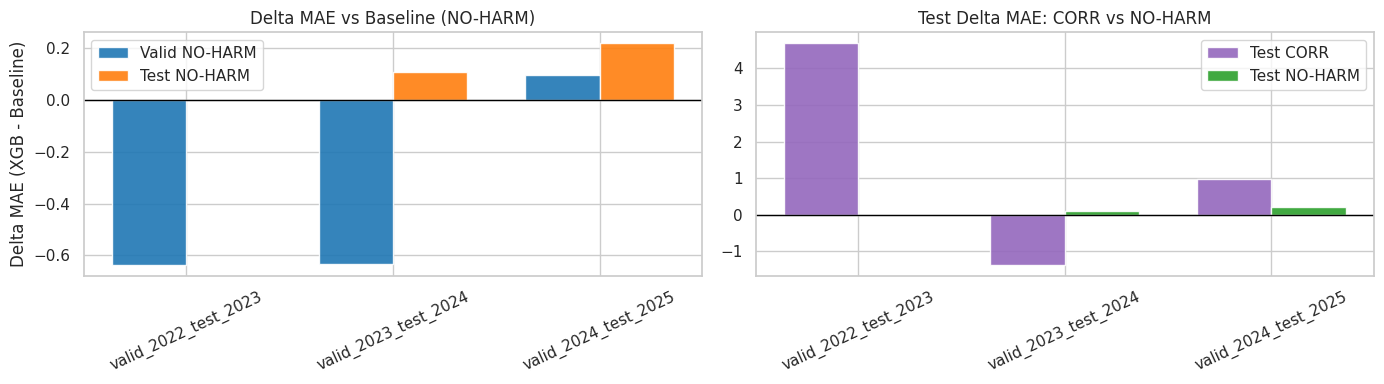

In [7]:
# Visual: delta MAE vs baseline by fold (NO-HARM primary, CORR diagnostic)

x = np.arange(len(reg_eval))
width = 0.36

fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=False)

axes[0].bar(x - width / 2, reg_eval["delta_valid_mae_noharm"], width=width, color="#1f77b4", alpha=0.9, label="Valid NO-HARM")
axes[0].bar(x + width / 2, reg_eval["delta_test_mae_noharm"], width=width, color="#ff7f0e", alpha=0.9, label="Test NO-HARM")
axes[0].axhline(0, color="black", lw=1)
axes[0].set_xticks(x)
axes[0].set_xticklabels(reg_eval["fold_name"], rotation=25)
axes[0].set_title("Delta MAE vs Baseline (NO-HARM)")
axes[0].set_ylabel("Delta MAE (XGB - Baseline)")
axes[0].legend(loc="best")

axes[1].bar(x - width / 2, reg_eval["delta_test_mae_corr"], width=width, color="#9467bd", alpha=0.9, label="Test CORR")
axes[1].bar(x + width / 2, reg_eval["delta_test_mae_noharm"], width=width, color="#2ca02c", alpha=0.9, label="Test NO-HARM")
axes[1].axhline(0, color="black", lw=1)
axes[1].set_xticks(x)
axes[1].set_xticklabels(reg_eval["fold_name"], rotation=25)
axes[1].set_title("Test Delta MAE: CORR vs NO-HARM")
axes[1].legend(loc="best")

plt.tight_layout()
plt.show()


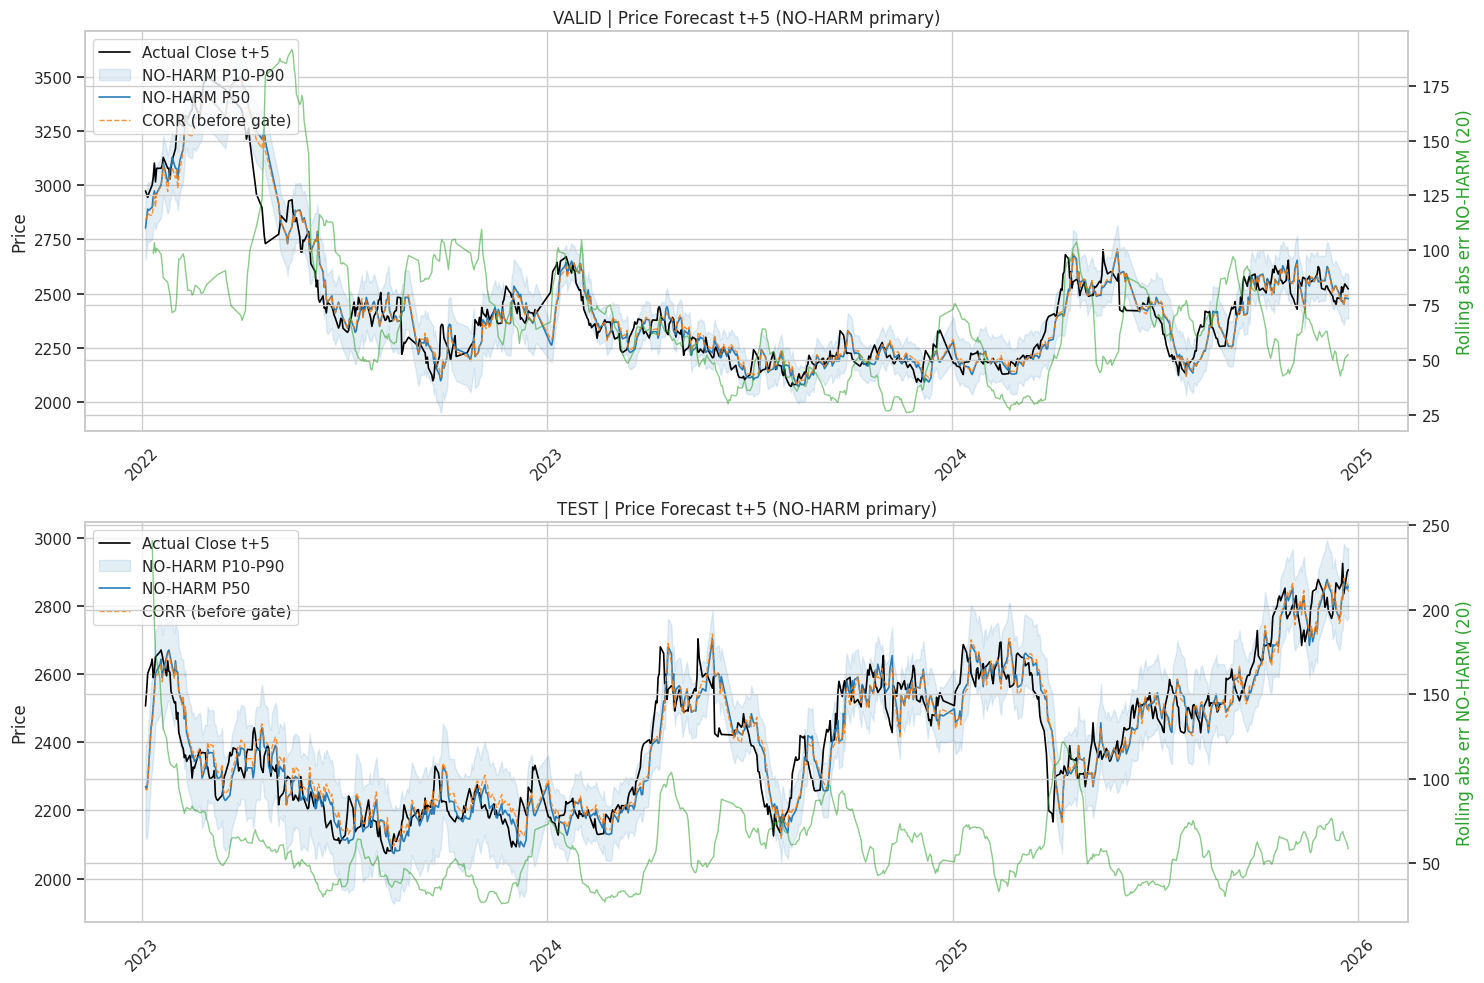

In [8]:
# Visual: actual vs predicted price over time (NO-HARM primary)

pred_df["Date"] = pd.to_datetime(pred_df["Date"])

fig, axes = plt.subplots(2, 1, figsize=(15, 10), sharex=False)
for ax, split in zip(axes, ["valid", "test"]):
    d = pred_df[pred_df["split"] == split].sort_values("Date")

    ax.plot(d["Date"], d["y_true_price_t5"], color="black", lw=1.2, label="Actual Close t+5")
    ax.fill_between(
        d["Date"],
        d["y_pred_p10_t5"],
        d["y_pred_p90_t5"],
        color="#1f77b4",
        alpha=0.12,
        label="NO-HARM P10-P90",
    )
    ax.plot(d["Date"], d["y_pred_p50_t5"], color="#1f77b4", lw=1.2, alpha=0.95, label="NO-HARM P50")
    ax.plot(d["Date"], d["y_pred_corr_t5"], color="#ff7f0e", lw=1.0, alpha=0.85, linestyle="--", label="CORR (before gate)")

    tmp = d.copy()
    tmp["abs_err_noharm"] = np.abs(tmp["y_true_price_t5"] - tmp["y_pred_p50_t5"])
    ax2 = ax.twinx()
    ax2.plot(tmp["Date"], tmp["abs_err_noharm"].rolling(20, min_periods=5).mean(), color="#2ca02c", alpha=0.55, lw=1)
    ax2.set_ylabel("Rolling abs err NO-HARM (20)", color="#2ca02c")

    ax.set_title(f"{split.upper()} | Price Forecast t+5 (NO-HARM primary)")
    ax.set_ylabel("Price")
    ax.xaxis.set_major_locator(mdates.YearLocator(1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.tick_params(axis="x", rotation=45)
    ax.legend(loc="upper left")

plt.tight_layout()
plt.show()


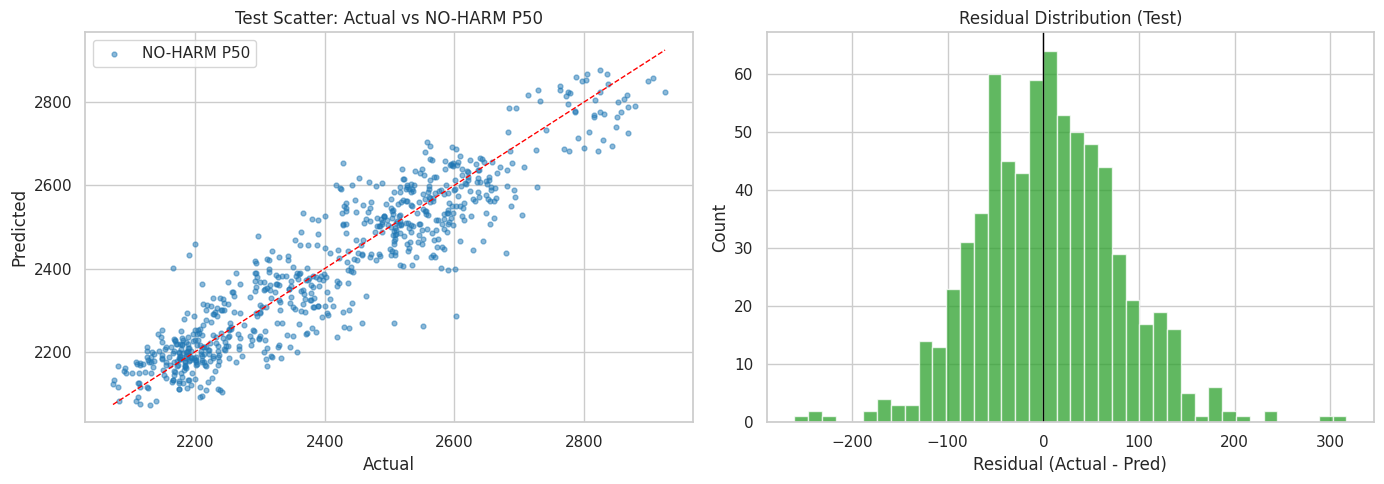

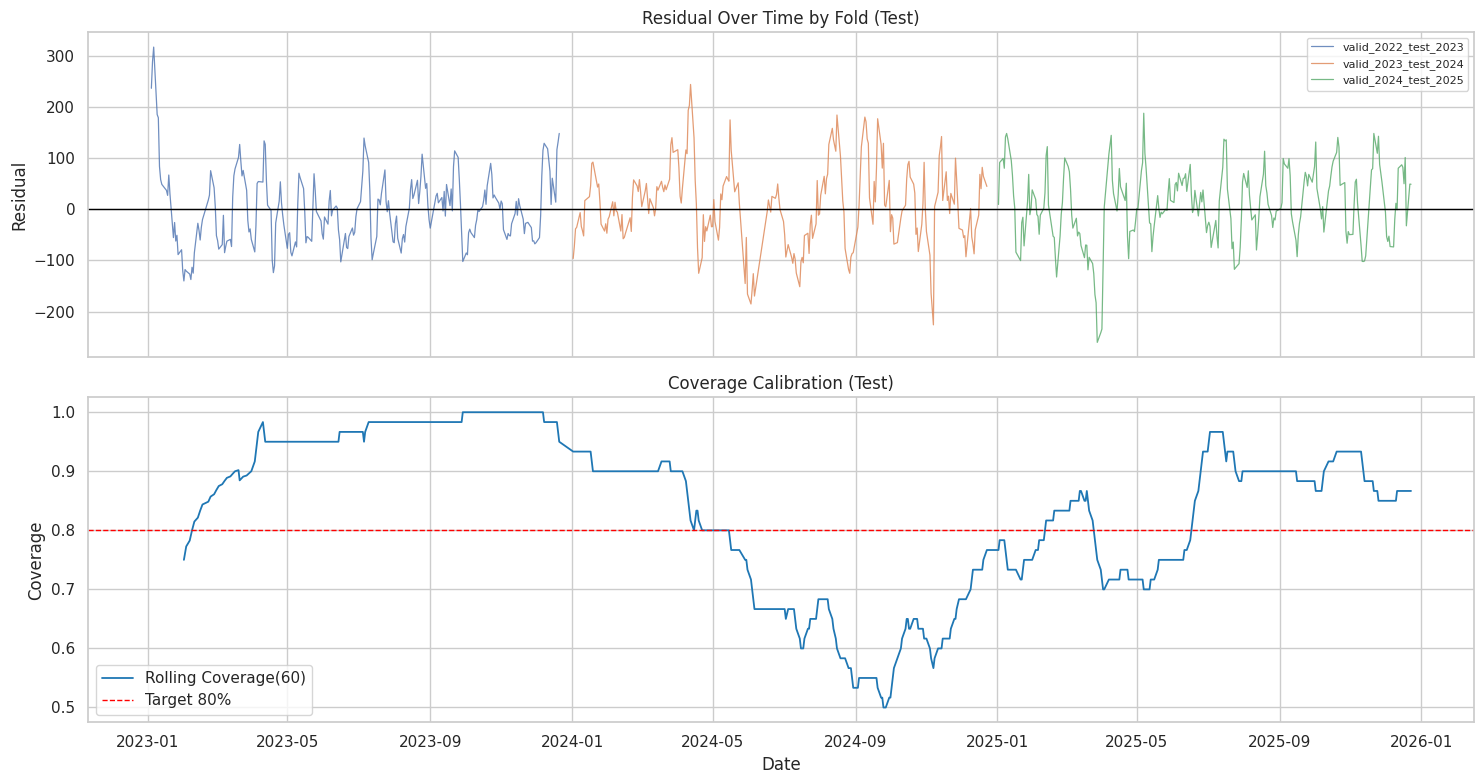

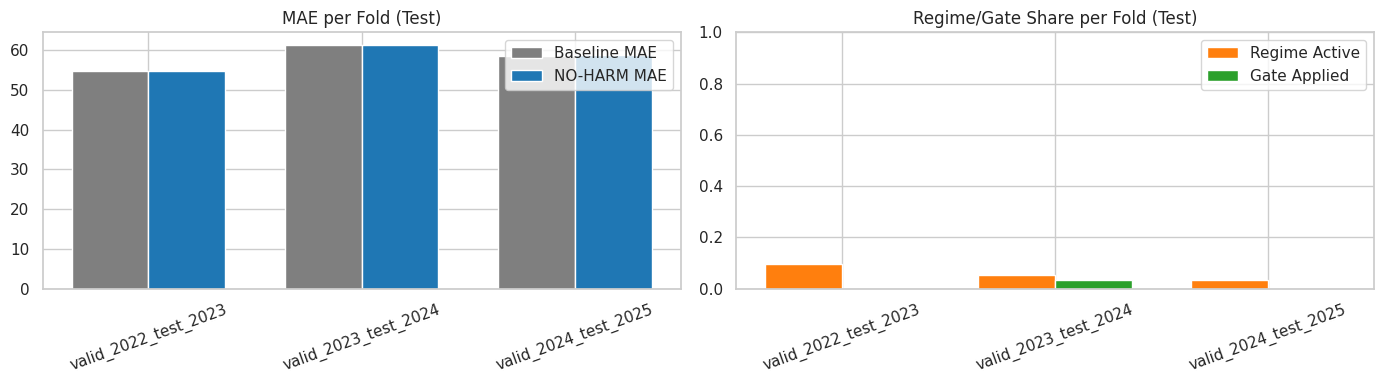

,test_corr_actual_noharm,test_corr_actual_corr,test_mae_noharm,test_mae_corr,test_mae_baseline_locked,test_smape_noharm,test_cov80_noharm,test_width80_noharm,test_regime_active_share,test_gate_applied_share
0,0.926789,0.922429,58.187091,59.546481,58.077387,0.024124,0.840278,214.049375,0.059722,0.011111


,fold_name,mae_noharm,mae_baseline,p90_abs_err,coverage80,regime_active_share,gate_applied_share
0,valid_2022_test_2023,54.603306,54.603306,113.950,0.950413,0.095041,0.000000
1,valid_2023_test_2024,61.342481,61.234914,128.525,0.715517,0.051724,0.034483
2,valid_2024_test_2025,58.736789,58.517148,115.000,0.849593,0.032520,0.000000


In [9]:
# Visual: diagnostics pack (test)

te = pred_df[pred_df["split"] == "test"].copy()
te["Date"] = pd.to_datetime(te["Date"])
te = te.sort_values(["Date", "fold_order"]).reset_index(drop=True)

te["resid_noharm"] = te["y_true_price_t5"] - te["y_pred_p50_t5"]
te["abs_err_noharm"] = np.abs(te["resid_noharm"])
te["abs_err_baseline"] = np.abs(te["y_true_price_t5"] - te["baseline_price_t5"])
te["hit80"] = ((te["y_true_price_t5"] >= te["y_pred_p10_t5"]) & (te["y_true_price_t5"] <= te["y_pred_p90_t5"])).astype(int)

# 1) Scatter + residual histogram
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(te["y_true_price_t5"], te["y_pred_p50_t5"], s=12, alpha=0.5, color="#1f77b4", label="NO-HARM P50")
mn = min(te["y_true_price_t5"].min(), te["y_pred_p50_t5"].min())
mx = max(te["y_true_price_t5"].max(), te["y_pred_p50_t5"].max())
axes[0].plot([mn, mx], [mn, mx], "--", color="red", lw=1)
axes[0].set_title("Test Scatter: Actual vs NO-HARM P50")
axes[0].set_xlabel("Actual")
axes[0].set_ylabel("Predicted")
axes[0].legend(loc="best")

axes[1].hist(te["resid_noharm"], bins=40, color="#2ca02c", alpha=0.75)
axes[1].axvline(0, color="black", lw=1)
axes[1].set_title("Residual Distribution (Test)")
axes[1].set_xlabel("Residual (Actual - Pred)")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

# 2) Residual time-series + rolling coverage calibration
fig, axes = plt.subplots(2, 1, figsize=(15, 8), sharex=True)

for fold_name, g in te.groupby("fold_name"):
    axes[0].plot(g["Date"], g["resid_noharm"], lw=0.9, alpha=0.8, label=fold_name)
axes[0].axhline(0, color="black", lw=1)
axes[0].set_title("Residual Over Time by Fold (Test)")
axes[0].set_ylabel("Residual")
axes[0].legend(loc="upper right", ncol=1, fontsize=8)

roll_cov = te["hit80"].rolling(60, min_periods=20).mean()
axes[1].plot(te["Date"], roll_cov, color="#1f77b4", lw=1.3, label="Rolling Coverage(60)")
axes[1].axhline(0.80, color="red", ls="--", lw=1, label="Target 80%")
axes[1].set_title("Coverage Calibration (Test)")
axes[1].set_ylabel("Coverage")
axes[1].set_xlabel("Date")
axes[1].legend(loc="best")

plt.tight_layout()
plt.show()

# 3) Error distribution per fold + regime/gate activity
fold_diag = te.groupby("fold_name", as_index=False).agg(
    mae_noharm=("abs_err_noharm", "mean"),
    mae_baseline=("abs_err_baseline", "mean"),
    p90_abs_err=("abs_err_noharm", lambda s: float(np.quantile(s, 0.90))),
    coverage80=("hit80", "mean"),
    regime_active_share=("regime_active", "mean"),
    gate_applied_share=("gate_applied", "mean"),
)

x = np.arange(len(fold_diag))
width = 0.36
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].bar(x - width/2, fold_diag["mae_baseline"], width=width, color="#7f7f7f", label="Baseline MAE")
axes[0].bar(x + width/2, fold_diag["mae_noharm"], width=width, color="#1f77b4", label="NO-HARM MAE")
axes[0].set_xticks(x)
axes[0].set_xticklabels(fold_diag["fold_name"], rotation=20)
axes[0].set_title("MAE per Fold (Test)")
axes[0].legend(loc="best")

axes[1].bar(x - width/2, fold_diag["regime_active_share"], width=width, color="#ff7f0e", label="Regime Active")
axes[1].bar(x + width/2, fold_diag["gate_applied_share"], width=width, color="#2ca02c", label="Gate Applied")
axes[1].set_xticks(x)
axes[1].set_xticklabels(fold_diag["fold_name"], rotation=20)
axes[1].set_ylim(0, 1)
axes[1].set_title("Regime/Gate Share per Fold (Test)")
axes[1].legend(loc="best")

plt.tight_layout()
plt.show()

corr_noharm = te[["y_true_price_t5", "y_pred_p50_t5"]].corr().iloc[0, 1]
corr_corr = te[["y_true_price_t5", "y_pred_corr_t5"]].corr().iloc[0, 1]

summary_diag = pd.DataFrame([
    {
        "test_corr_actual_noharm": float(corr_noharm),
        "test_corr_actual_corr": float(corr_corr),
        "test_mae_noharm": float(mean_absolute_error(te["y_true_price_t5"], te["y_pred_p50_t5"])),
        "test_mae_corr": float(mean_absolute_error(te["y_true_price_t5"], te["y_pred_corr_t5"])),
        "test_mae_baseline_locked": float(mean_absolute_error(te["y_true_price_t5"], te["baseline_price_t5"])),
        "test_smape_noharm": smape(te["y_true_price_t5"], te["y_pred_p50_t5"]),
        "test_cov80_noharm": float(te["hit80"].mean()),
        "test_width80_noharm": float((te["y_pred_p90_t5"] - te["y_pred_p10_t5"]).mean()),
        "test_regime_active_share": float(te["regime_active"].mean()),
        "test_gate_applied_share": float(te["gate_applied"].mean()),
    }
])

display(summary_diag)
display(fold_diag)


In [10]:
# Final decision (price model, NO-HARM + regime gated)

leakage_pass = bool(leak_status == "PASS")

robust_row = robust.iloc[0]
folds_ok = bool(robust_row["folds_meet_min"])
all_test_folds_win_noharm = bool(robust_row["all_test_folds_win_noharm"])
all_valid_folds_win_noharm = bool(robust_row["all_valid_folds_win_noharm"])
sign_flip_ok_noharm = bool(robust_row["sign_flip_ok_noharm"])
robustness_pass_strict_noharm = bool(robust_row["robust_pass_strict_noharm"])

hard_fail_reasons = []
if not leakage_pass:
    hard_fail_reasons.append("leakage_fail")
if not folds_ok:
    hard_fail_reasons.append("insufficient_folds")
if not all_valid_folds_win_noharm:
    hard_fail_reasons.append("valid_not_outperform_locked_baseline")
if not all_test_folds_win_noharm:
    hard_fail_reasons.append("noharm_model_loses_to_locked_baseline_on_some_test_folds")
if not sign_flip_ok_noharm:
    hard_fail_reasons.append("noharm_sign_flip_rate_too_high")

overall_go = bool(leakage_pass and robustness_pass_strict_noharm)

optuna_feasible_trial_count = 0
if "tuning_df" in globals() and isinstance(tuning_df, pd.DataFrame) and not tuning_df.empty:
    if {"state", "fail_count_valid", "mean_delta_valid_noharm"}.issubset(set(tuning_df.columns)):
        optuna_feasible_trial_count = int(
            (
                (tuning_df["state"] == "complete")
                & (tuning_df["fail_count_valid"] <= 0)
                & (tuning_df["mean_delta_valid_noharm"] <= -MUST_WIN_VALID_EPS)
            ).sum()
        )

decision = {
    "target": f"close_t{H}",
    "model_type": "xgboost_residual_correction_with_noharm_and_regime_gate",
    "primary_gate_stream": "xgb_noharm_price_p50",
    "output_contract": [f"price_p10_t{H}", f"price_p50_t{H}", f"price_p90_t{H}"],
    "leakage_pass": leakage_pass,
    "robustness_pass_strict_noharm": robustness_pass_strict_noharm,
    "folds_meet_min": folds_ok,
    "all_test_folds_win_noharm": all_test_folds_win_noharm,
    "all_valid_folds_win_noharm": all_valid_folds_win_noharm,
    "sign_flip_ok_noharm": sign_flip_ok_noharm,
    "overall_go_price_model": overall_go,
    "hard_fail_reasons": hard_fail_reasons,
    "mean_delta_test_mae_noharm": float(reg_eval["delta_test_mae_noharm"].mean()),
    "worst_delta_test_mae_noharm": float(reg_eval["delta_test_mae_noharm"].max()),
    "mean_delta_test_mae_corr": float(reg_eval["delta_test_mae_corr"].mean()),
    "mean_baseline_test_mae": float(reg_eval["baseline_test_mae"].mean()),
    "mean_xgb_noharm_test_mae": float(reg_eval["xgb_noharm_test_mae"].mean()),
    "mean_xgb_corr_test_mae": float(reg_eval["xgb_corr_test_mae"].mean()),
    "mean_xgb_noharm_test_smape": float(reg_eval["xgb_noharm_test_smape"].mean()),
    "mean_xgb_noharm_test_dir_acc_nonzero": float(np.nanmean(reg_eval["xgb_noharm_test_dir_acc_nonzero"])),
    "mean_xgb_noharm_test_dir_nonzero_share": float(np.nanmean(reg_eval["xgb_noharm_test_dir_nonzero_share"])),
    "mean_noharm_test_cov80": float(reg_eval["noharm_test_cov80"].mean()),
    "mean_regime_active_share_test": float(reg_eval["regime_active_share_test"].mean()),
    "mean_gate_applied_share_test": float(reg_eval["gate_applied_share_test"].mean()),
    "feature_count": int(len(FEATURES)),
    "selected_params_source": selected_params_source,
    "optuna_feasible_trial_count": int(optuna_feasible_trial_count),
    "reg_params_used": REG_PARAMS_USED,
    "noharm_tau_mult_used": float(NOHARM_TAU_MULT_USED),
    "noharm_tau_mult_min": float(NOHARM_TAU_MULT_MIN),
    "regime_vol_z_used": float(REGIME_VOL_Z_USED),
    "regime_active_target_low": float(REGIME_ACTIVE_TARGET_LOW),
    "regime_active_target_high": float(REGIME_ACTIVE_TARGET_HIGH),
    "use_optuna": bool(USE_OPTUNA),
    "optuna_trials": int(OPTUNA_N_TRIALS) if USE_OPTUNA else 0,
}

pd.DataFrame([decision])


,target,model_type,primary_gate_stream,output_contract,leakage_pass,robustness_pass_strict_noharm,folds_meet_min,all_test_folds_win_noharm,all_valid_folds_win_noharm,sign_flip_ok_noharm,...,selected_params_source,optuna_feasible_trial_count,reg_params_used,noharm_tau_mult_used,noharm_tau_mult_min,regime_vol_z_used,regime_active_target_low,regime_active_target_high,use_optuna,optuna_trials
0,close_t5,xgboost_residual_correction_with_noharm_and_re...,xgb_noharm_price_p50,"[price_p10_t5, price_p50_t5, price_p90_t5]",True,False,True,False,False,False,...,optuna_best_nonfeasible,0,"{'objective': 'reg:squarederror', 'n_estimator...",0.401772,0.2,1.973735,0.2,0.4,True,80


In [11]:
# Save artifacts
SAVE_ARTIFACTS = False
prefix = "xgb_v6_price_t5"

if SAVE_ARTIFACTS:
    reg_eval.to_csv(OUT_DIR / f"{prefix}_fold_results.csv", index=False)
    pred_df.to_csv(OUT_DIR / f"{prefix}_predictions.csv", index=False)
    audit_df.to_csv(OUT_DIR / f"{prefix}_leakage_audit.csv", index=False)
    viol_df.to_csv(OUT_DIR / f"{prefix}_leakage_violations.csv", index=False)
    summary.to_csv(OUT_DIR / f"{prefix}_summary.csv", index=False)
    robust.to_csv(OUT_DIR / f"{prefix}_robustness.csv", index=False)
    if "tuning_df" in globals() and isinstance(tuning_df, pd.DataFrame) and not tuning_df.empty:
        tuning_df.to_csv(OUT_DIR / f"{prefix}_optuna_trials.csv", index=False)
    (OUT_DIR / f"{prefix}_decision.json").write_text(json.dumps(decision, indent=2))
    print("saved artifacts with prefix:", prefix)
else:
    print("SAVE_ARTIFACTS=False -> artifacts not written")



SAVE_ARTIFACTS=False -> artifacts not written


## Catatan Interpretasi

- Jika `overall_go_price_model=True`: model **price** t+5 (stream `NO-HARM + regime gate`) lolos gate ketat dan bisa dipertimbangkan lanjut.
- Jika `False`: gunakan baseline locked sebagai referensi operasional sementara, dan perlakukan output `P10/P50/P90` model sebagai skenario analitis (belum production-go).
- Notebook ini memakai **must-win valid policy** saat tuning: trial yang tidak menang terhadap baseline locked di valid akan dipenalti keras.
- Untuk pelaporan bisnis, tampilkan selalu `P10/P50/P90`, coverage, residual plot, dan regime/gate share agar keputusan tidak bergantung pada satu angka price.
